In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.impute import SimpleImputer

# Exploratory Data Analysis (EDA)

### Task 1: Setup and basic inspection

In [2]:
df = pd.read_csv("../data/processed/features_selected.csv")

In [3]:
df.head()

,Diabetes_binary,PHYSHLTH,_SMOKER3,GENHLTH,CHECKUP1,DROCDY3_,_RFBING5,_DRDXAR1,PNEUVAC3,_AIDTST3,...,PERSDOC2,CVDSTRK3,_TOTINDA,CHCKIDNY,_CHLDCNT,INCOME2,EDUCA,CVDCRHD4,CVDINFR4,_ASTHMS1
0,0,88.0,1.0,4.0,1.0,4.300000e+01,1.0,1.0,7.0,2.0,...,2.0,2.0,2.0,2.0,1.0,4.0,4.0,2.0,2.0,3.0
1,0,12.0,1.0,4.0,1.0,9.000000e+02,9.0,1.0,2.0,2.0,...,1.0,2.0,2.0,2.0,1.0,5.0,3.0,2.0,2.0,3.0
2,0,88.0,3.0,2.0,1.0,1.400000e+01,1.0,2.0,2.0,2.0,...,1.0,2.0,1.0,2.0,1.0,5.0,6.0,2.0,2.0,3.0
3,0,88.0,4.0,3.0,7.0,9.000000e+02,9.0,2.0,2.0,2.0,...,1.0,2.0,9.0,2.0,9.0,77.0,4.0,2.0,2.0,3.0
4,1,25.0,3.0,5.0,1.0,5.397605e-79,1.0,1.0,2.0,1.0,...,1.0,2.0,1.0,2.0,2.0,1.0,3.0,2.0,2.0,3.0


In [4]:
df.columns

Index(['Diabetes_binary', 'PHYSHLTH', '_SMOKER3', 'GENHLTH', 'CHECKUP1',
       'DROCDY3_', '_RFBING5', '_DRDXAR1', 'PNEUVAC3', '_AIDTST3', 'HLTHPLN1',
       'MENTHLTH', '_AGE_G', 'QLACTLM2', 'CHCOCNCR', '_RFHLTH', 'HAVARTH3',
       'HIVTST6', 'MEDCOST', 'CHCSCNCR', '_AGE65YR', 'EXERANY2', 'SEX',
       'DRNKANY5', '_HCVU651', '_AGEG5YR', '_BMI5', 'ALCDAY5', 'ADDEPEV2',
       'PERSDOC2', 'CVDSTRK3', '_TOTINDA', 'CHCKIDNY', '_CHLDCNT', 'INCOME2',
       'EDUCA', 'CVDCRHD4', 'CVDINFR4', '_ASTHMS1'],
      dtype='object')

In [5]:
df.describe()

,Diabetes_binary,PHYSHLTH,_SMOKER3,GENHLTH,CHECKUP1,DROCDY3_,_RFBING5,_DRDXAR1,PNEUVAC3,_AIDTST3,...,PERSDOC2,CVDSTRK3,_TOTINDA,CHCKIDNY,_CHLDCNT,INCOME2,EDUCA,CVDCRHD4,CVDINFR4,_ASTHMS1
count,2.374745e+06,2.374745e+06,2.374745e+06,2.374745e+06,2.374745e+06,2.374745e+06,2.374745e+06,2.374745e+06,2.374745e+06,2.374745e+06,...,2.374745e+06,2.374745e+06,2.374745e+06,2.374739e+06,2.374745e+06,2.364626e+06,2.371671e+06,2.374745e+06,2.374745e+06,2.374745e+06
mean,1.533280e-01,6.067540e+01,3.439542e+00,2.590944e+00,1.600451e+00,5.860796e+01,1.567962e+00,1.661055e+00,2.101758e+00,1.971951e+00,...,1.404800e+00,1.971978e+00,1.579079e+00,1.982212e+00,1.555202e+00,1.791037e+01,4.877041e+00,1.982548e+00,1.964092e+00,2.819890e+00
std,3.603035e-01,3.702498e+01,1.353383e+00,1.141381e+00,1.261952e+00,1.911127e+02,1.843025e+00,4.733512e-01,1.617264e+00,1.380802e+00,...,8.251291e-01,3.267735e-01,1.596648e+00,3.367750e-01,1.139936e+00,2.976216e+01,1.083693e+00,5.249843e-01,4.233112e-01,7.779499e-01
min,0.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,5.397605e-79,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,...,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00
25%,0.000000e+00,1.500000e+01,3.000000e+00,2.000000e+00,1.000000e+00,5.397605e-79,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,...,1.000000e+00,2.000000e+00,1.000000e+00,2.000000e+00,1.000000e+00,4.000000e+00,4.000000e+00,2.000000e+00,2.000000e+00,3.000000e+00
50%,0.000000e+00,8.800000e+01,4.000000e+00,3.000000e+00,1.000000e+00,3.000000e+00,1.000000e+00,2.000000e+00,2.000000e+00,2.000000e+00,...,1.000000e+00,2.000000e+00,1.000000e+00,2.000000e+00,1.000000e+00,7.000000e+00,5.000000e+00,2.000000e+00,2.000000e+00,3.000000e+00
75%,0.000000e+00,8.800000e+01,4.000000e+00,3.000000e+00,2.000000e+00,2.700000e+01,1.000000e+00,2.000000e+00,2.000000e+00,2.000000e+00,...,1.000000e+00,2.000000e+00,2.000000e+00,2.000000e+00,2.000000e+00,8.000000e+00,6.000000e+00,2.000000e+00,2.000000e+00,3.000000e+00
max,1.000000e+00,9.900000e+01,9.000000e+00,9.000000e+00,9.000000e+00,9.000000e+02,9.000000e+00,2.000000e+00,9.000000e+00,9.000000e+00,...,9.000000e+00,9.000000e+00,9.000000e+00,9.000000e+00,9.000000e+00,9.900000e+01,9.000000e+00,9.000000e+00,9.000000e+00,9.000000e+00


### Task 2: Univariate Analysis

In [6]:
print(df["_BMI5"].describe()/100)
print(f"Skewness: {(df['_BMI5']/100).skew():.2f}")

count    22287.980000
mean        27.819758
std          6.192935
min         12.010000
25%         23.670000
50%         26.630000
75%         30.790000
max         99.950000
Name: _BMI5, dtype: float64
Skewness: 1.57


In [7]:
print((df["_BMI5"]/100 > 60).sum())
print(df[df["_BMI5"]/100 > 60]["_BMI5"].value_counts().head(10))

3672
_BMI5
8651.0    96
6008.0    89
8137.0    89
7941.0    75
8167.0    72
8404.0    68
7318.0    66
7127.0    63
7724.0    61
7517.0    60
Name: count, dtype: int64


In [8]:
df = df.drop(df[df["_BMI5"]>6000].index)
print(df["_BMI5"].max()/100)
print(df["_BMI5"].shape)

60.0
(2371073,)


In [9]:
print(type(df))
print(df.shape)

<class 'pandas.core.frame.DataFrame'>
(2371073, 39)


#### Unusual BMI Detection
1) I found out that 3672 rows of the BMI column had medically impossible values (like 86.51,81.37)
2) I classified these as data errors and not real BMI values
3) I decided to drop them as dropping 3672 rows out of 2.37M is negligible (0.15%) 

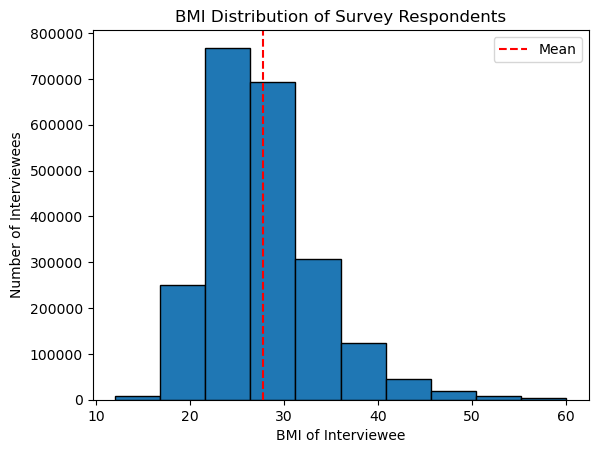

In [10]:
plt.hist(df["_BMI5"]/100,bins=10,edgecolor='black')
plt.xlabel("BMI of Interviewee")
plt.ylabel("Number of Interviewees")
plt.title("BMI Distribution of Survey Respondents")
plt.axvline(df["_BMI5"].mean()/100, color='red', linestyle='--', label='Mean')
plt.legend()
#plt.savefig("../reports/univariate/bmi_distribution.png", bbox_inches='tight', dpi=150)
plt.show()

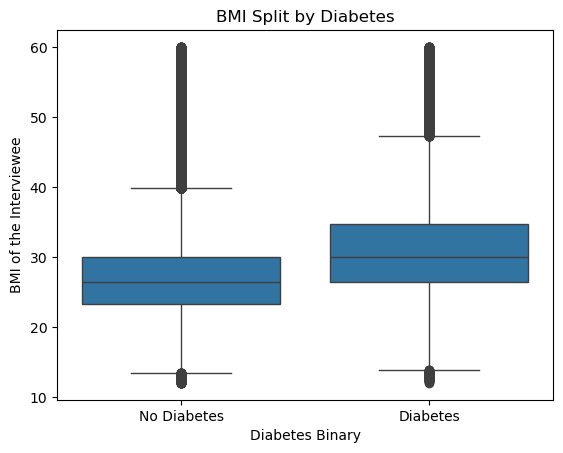

In [11]:
df["_BMI5_scaled"] = df["_BMI5"]/100
sns.boxplot(x='Diabetes_binary',y="_BMI5_scaled",data=df)
plt.xticks([0,1],["No Diabetes","Diabetes"])
plt.xlabel("Diabetes Binary")
plt.ylabel("BMI of the Interviewee")
plt.title("BMI Split by Diabetes")
#plt.savefig("../reports/bivariate/bmi_vs_diabetes.png",bbox_inches = 'tight',dpi = 150)
plt.show()

In [12]:
df.groupby("Diabetes_binary")["_BMI5"].median()/100

Diabetes_binary
0    26.43
1    30.04
Name: _BMI5, dtype: float64

#### BMI Observation 
The median BMI for diabetic patients is noticeably higher than for non-diabetic patients, suggesting that higher BMI is associated with increased diabetes risk. This confirms BMI as a high discriminative power feature for our model. Median BMI for non-diabetic patients is 26.43 vs 30.04 for diabetic patients — a difference of 3.61 points

In [13]:
df["EXERANY2"] = df["EXERANY2"].replace({7.0:np.nan,9.0:np.nan})
df = df.dropna(subset=["EXERANY2"])

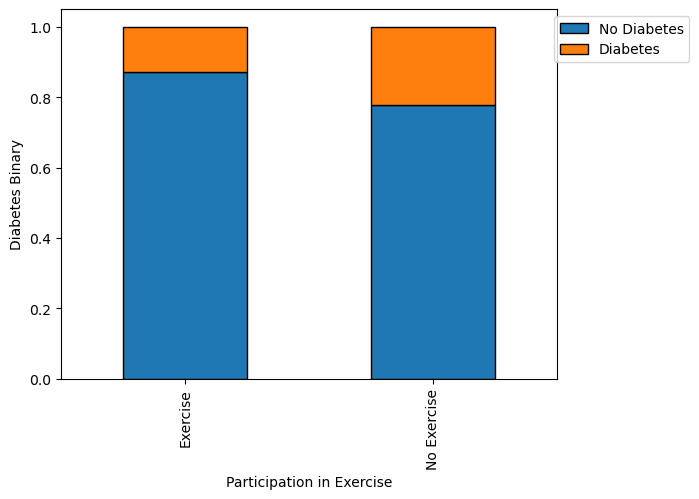

In [14]:
ct = pd.crosstab(df["EXERANY2"],df["Diabetes_binary"],normalize="index")
ct.plot(kind='bar',stacked=True,edgecolor = 'black')
plt.xticks([1,0],["No Exercise","Exercise"])
plt.xlabel("Participation in Exercise")
plt.ylabel("Diabetes Binary")
plt.legend(["No Diabetes","Diabetes"],bbox_to_anchor=(1.28, 1))
plt.style.use("ggplot")
#plt.savefig("../reports/bivariate/diabetes_vs_exercise.png",bbox_inches = 'tight',dpi = 150)
plt.show()

### Exercise Observation
1) This stacked bar chart shows the proportion of diabetic vs non-diabetic patients among those who exercise (EXERANY2=1) and those who don't (EXERANY2=2).
2) Percentage of People who are diabetic vs non-diabetic
    - 87% of people who exercise are Not Diabetic and 13% are Diabetic
    - 77% of people who dont exercise are Not Diabetic and 23% are Diabetic
3) It was found that people who exercise have lower chance of having diabetes as compared to people who dont.

In [15]:
df["PHYSHLTH"].value_counts()

PHYSHLTH
88.0    1467059
30.0     183191
2.0      128735
1.0       98753
3.0       75235
5.0       67298
10.0      49304
15.0      45555
7.0       42335
77.0      41310
4.0       39554
20.0      29381
14.0      24008
25.0      11991
6.0       11425
99.0      10666
8.0        7448
21.0       5889
12.0       4804
28.0       4424
29.0       2087
9.0        1712
18.0       1418
16.0       1180
27.0       1033
17.0        831
26.0        696
22.0        672
24.0        614
13.0        601
11.0        570
23.0        493
19.0        257
Name: count, dtype: int64

In [16]:
df["PHYSHLTH"] = df["PHYSHLTH"].replace({88:0,77:np.nan,99:np.nan})
df = df.dropna(subset="PHYSHLTH")
df["PHYSHLTH"].value_counts()

PHYSHLTH
0.0     1467059
30.0     183191
2.0      128735
1.0       98753
3.0       75235
5.0       67298
10.0      49304
15.0      45555
7.0       42335
4.0       39554
20.0      29381
14.0      24008
25.0      11991
6.0       11425
8.0        7448
21.0       5889
12.0       4804
28.0       4424
29.0       2087
9.0        1712
18.0       1418
16.0       1180
27.0       1033
17.0        831
26.0        696
22.0        672
24.0        614
13.0        601
11.0        570
23.0        493
19.0        257
Name: count, dtype: int64

Diabetes_binary
0    0.0
1    1.0
Name: PHYSHLTH, dtype: float64


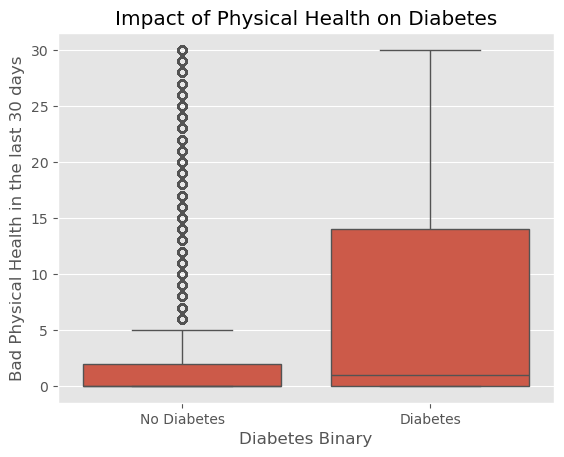

In [17]:
print(df.groupby("Diabetes_binary")["PHYSHLTH"].median())
sns.boxplot(x="Diabetes_binary",y="PHYSHLTH",data=df)
plt.xticks([0,1],["No Diabetes","Diabetes"])
plt.xlabel("Diabetes Binary")
plt.ylabel("Bad Physical Health in the last 30 days")
plt.title("Impact of Physical Health on Diabetes")
#plt.savefig("../reports/bivariate/physhlth_vs_diabetes.png", bbox_inches='tight', dpi=150)
plt.show()

In [18]:
# What % of each class reports AT LEAST ONE bad health day
df["ADDEPEV2"].value_counts()

ADDEPEV2
2.0    1868569
1.0     430885
7.0       7355
9.0       1732
Name: count, dtype: int64

### Physical Health (PHYSHLTH) Observation
1) PHYSHLTH is a zero-inflated feature — a large proportion of respondents 
   report 0 bad health days, which makes median alone a misleading statistic
   - Median for non-diabetic patients: 0.0 days
   - Median for diabetic patients: 1.0 days

2) A more meaningful metric is the proportion of respondents reporting 
   at least one bad health day:
   - Non-diabetic patients: 33.8% report at least one bad health day
   - Diabetic patients: 51.4% report at least one bad health day

3) This ~18 percentage point difference confirms PHYSHLTH has meaningful 
   discriminative power despite the low median difference

4) Note: Reverse causality may apply — diabetes itself causes poor physical 
   health, so the direction of this relationship cannot be confirmed from 
   survey data alone

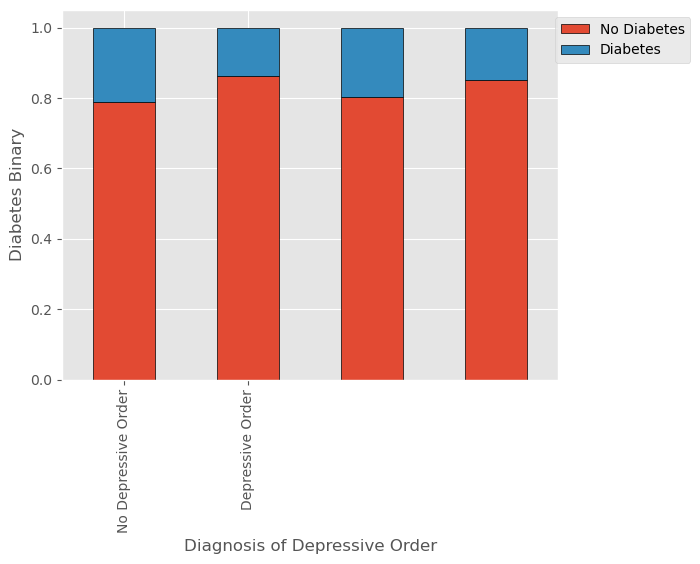

In [19]:
dct = pd.crosstab(df["ADDEPEV2"],df["Diabetes_binary"],normalize="index")
dct.plot(kind='bar',stacked=True,edgecolor = 'black')
plt.xticks([1,0],["Depressive Order","No Depressive Order"])
plt.xlabel("Diagnosis of Depressive Order")
plt.ylabel("Diabetes Binary")
plt.legend(["No Diabetes","Diabetes"],bbox_to_anchor=(1.28, 1))
plt.style.use("ggplot")
#plt.savefig("../reports/bivariate/depressionvsdiabetes.png",bbox_inches= 'tight', dpi=150)
plt.show()

### ADDEPEV2 (Depression) Observation

1) People with depressive disorder show ~20% diabetes rate vs ~13% without

2) Clear difference between the two groups

3) Reverse causality applies — diabetes causes chronic stress, fatigue, and lifestyle restrictions which can trigger depression. Direction cannot be confirmed from survey data.

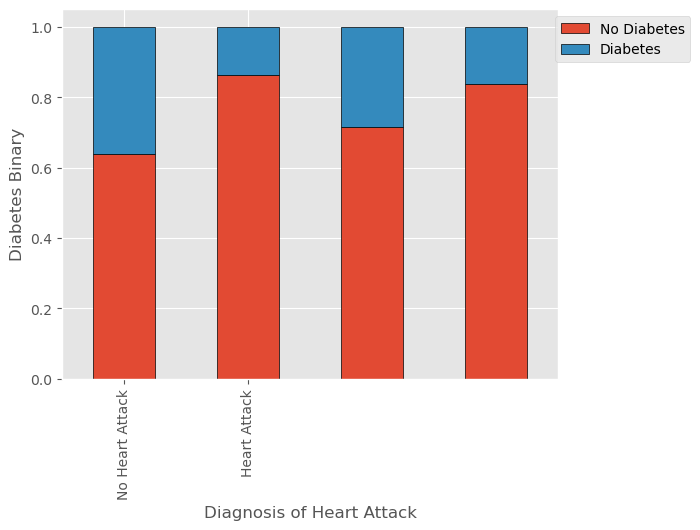

In [20]:
cct = pd.crosstab(df["CVDINFR4"],df["Diabetes_binary"],normalize="index")
cct.plot(kind='bar',stacked=True,edgecolor = 'black')
plt.xticks([1,0],["Heart Attack","No Heart Attack"])
plt.xlabel("Diagnosis of Heart Attack")
plt.ylabel("Diabetes Binary")
plt.legend(["No Diabetes","Diabetes"],bbox_to_anchor=(1.28, 1))
plt.style.use("ggplot")
#plt.savefig("../reports/bivariate/heartattackvsdiabetes.png",bbox_inches= 'tight', dpi=150)
plt.show()

### CVDINFR4 (Heart Attack) Observation

1) People with heart attack history show ~37% diabetes rate vs ~13% without

2) Strongest visual separation of all four plots — nearly 3x higher diabetes proportion

3) Metabolic syndrome links both conditions — insulin resistance drives both heart disease and diabetes
Reverse causality applies — diabetes damages blood vessels over time leading to heart attacks

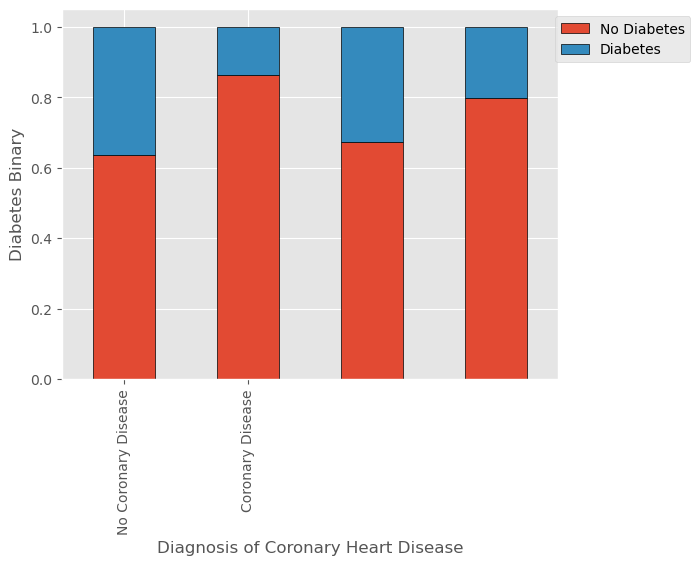

In [21]:
cvct = pd.crosstab(df["CVDCRHD4"],df["Diabetes_binary"],normalize="index")
cvct.plot(kind='bar',stacked=True,edgecolor = 'black')
plt.xticks([1,0],["Coronary Disease","No Coronary Disease"])
plt.xlabel("Diagnosis of Coronary Heart Disease")
plt.ylabel("Diabetes Binary")
plt.legend(["No Diabetes","Diabetes"],bbox_to_anchor=(1.28, 1))
plt.style.use("ggplot")
#plt.savefig("../reports/bivariate/coronarydiseasevsdiabetes.png",bbox_inches= 'tight', dpi=150)
plt.show()

### CVDCRHD4 (Coronary Heart Disease) Observation

1) Nearly identical pattern to CVDINFR4 — ~37% diabetes rate in coronary disease group

2) Makes sense — heart attack and coronary disease are closely related conditions

3) Both share the same metabolic syndrome pathway

In [22]:
df["_RFBING5"] = df["_RFBING5"].replace({1.0:0})
df["_RFBING5"] = df["_RFBING5"].replace({2.0:1})
df["_RFBING5"].value_counts()

_RFBING5
0.0    1910198
1.0     275888
9.0     122467
Name: count, dtype: int64

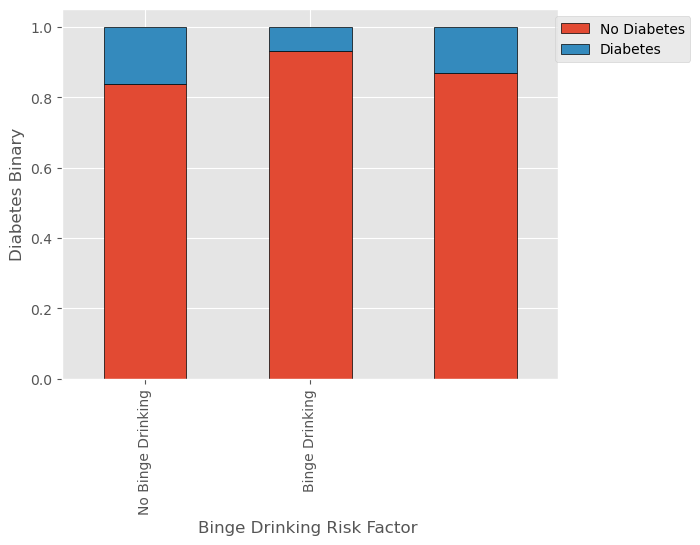

In [23]:
rct = pd.crosstab(df["_RFBING5"],df["Diabetes_binary"],normalize="index")
rct.plot(kind='bar',stacked=True,edgecolor = 'black')
plt.xticks([1,0],["Binge Drinking","No Binge Drinking"])
plt.xlabel("Binge Drinking Risk Factor ")
plt.ylabel("Diabetes Binary")
plt.legend(["No Diabetes","Diabetes"],bbox_to_anchor=(1.28, 1))
plt.style.use("ggplot")
#plt.savefig("../reports/bivariate/bingedrinkingvsdiabetes.png",bbox_inches= 'tight', dpi=150)
plt.show()

### _RFBING5 (Binge Drinking) Observation

1) Binge drinkers show lower diabetes rate (~7%) vs non-binge drinkers (~16%)

2) Counterintuitive result — classic reverse causality

3) Diabetic patients are medically advised to stop or reduce alcohol consumption

4) Healthy individuals are more likely to be active binge drinkers

## Day 4 — Exploratory Data Analysis

### Setup
- Loaded cleaned dataset from data/processed/features_selected.csv
- Created reports/univariate/ and reports/bivariate/ directories

### Univariate Analysis

#### BMI Distribution
- Distribution is right-skewed (skewness = 1.57)
- Majority of respondents have BMI between 20-40
- Mean BMI: ~27.8 (overweight range)
- Outliers detected above BMI 60 — 3,672 rows with impossible values 
  like 86.51, 81.37 identified as data errors and dropped (0.15% loss)
- Right skew confirms median is preferred over mean for BMI imputation

### Bivariate Analysis

#### BMI vs Diabetes (_BMI5)
- Median BMI for non-diabetic patients: 26.43 (overweight range)
- Median BMI for diabetic patients: 30.04 (obese range)
- Difference of 3.61 BMI points — clinically significant
- The 25-30 → 30+ boundary aligns with established medical literature 
  where obesity threshold marks accelerated diabetes risk
- Confirms _BMI5 as high discriminative power feature

#### Exercise vs Diabetes (EXERANY2)
- Sentinel values 7.0 and 9.0 removed before analysis
- People who don't exercise show higher diabetes proportion
- Reverse causality noted — diabetic patients are prescribed exercise 
  as part of disease management, which can inflate exercise rates 
  among diabetic respondents
- BRFSS 1/2 encoding recoded to ML convention 1/0

#### Physical Health vs Diabetes (PHYSHLTH)
- Zero-inflated feature — large proportion report 0 bad health days
- Median alone is misleading due to zero inflation:
  - Non-diabetic median: 0.0 days
  - Diabetic median: 1.0 days
- More meaningful metric — proportion reporting at least one bad health day:
  - Non-diabetic: 33.8%
  - Diabetic: 51.4%
- ~18 percentage point difference confirms discriminative power
- Reverse causality applies — diabetes causes poor physical health directly
- 88 recoded to 0 (no bad health days), 77/99 dropped as sentinels

#### Depression vs Diabetes (ADDEPEV2)
- Depressive disorder group shows ~20% diabetes rate vs ~13% without
- Meaningful separation between groups
- Reverse causality applies — chronic illness like diabetes triggers 
  depression through lifestyle restrictions and metabolic changes

#### Heart Attack vs Diabetes (CVDINFR4)
- Heart attack group shows ~37% diabetes rate vs ~13% without
- Strongest separation of all binary features analyzed
- Nearly 3x higher diabetes proportion in heart attack group
- Metabolic syndrome drives both conditions simultaneously
- Reverse causality applies — diabetic vascular damage leads to heart attacks

#### Coronary Heart Disease vs Diabetes (CVDCRHD4)
- Nearly identical pattern to CVDINFR4 (~37% diabetes rate)
- Expected — heart attack and coronary disease share the same 
  metabolic syndrome pathway
- High inter-correlation between CVDINFR4 and CVDCRHD4 suspected — 
  will verify in correlation matrix

#### Binge Drinking vs Diabetes (_RFBING5)
- Binge drinkers show lower diabetes rate (~7%) vs non-binge drinkers (~16%)
- Counterintuitive — reverse causality explains this completely
- Diabetic patients advised to reduce/stop alcohol consumption
- Encoding corrected: 1=no binge drinking → 0, 2=binge drinking → 1
- Sentinel value 9.0 removed before analysis

### Key Themes from Day 4 EDA
1. Reverse causality is present in almost every feature analyzed — 
   survey data cannot confirm direction of relationships
2. Zero-inflated features require proportion analysis, not just median
3. BMI and cardiovascular conditions show strongest visual separation 
   between diabetic and non-diabetic groups
4. All binary columns recoded from BRFSS convention (1/2) to ML 
   convention (1/0) for model compatibility

### Saved Outputs
- reports/univariate/bmi_distribution.png
- reports/bivariate/bmi_vs_diabetes.png
- reports/bivariate/diabetes_vs_exercise.png
- reports/bivariate/physhlth_vs_diabetes.png
- reports/bivariate/depression_vs_diabetes.png
- reports/bivariate/heartattack_vs_diabetes.png
- reports/bivariate/coronary_vs_diabetes.png
- reports/bivariate/binge_vs_diabetes.png

In [24]:
binary_cols = ["EXERANY2", "ADDEPEV2","PNEUVAC3","HLTHPLN1","QLACTLM2","CHCOCNCR","HAVARTH3","HIVTST6","MEDCOST","CHCSCNCR","SEX","DRNKANY5","_HCVU651","CVDSTRK3","CHCKIDNY","CVDCRHD4","CVDINFR4"]   

In [25]:
df_backup = df.copy()

In [26]:
for col in binary_cols:
    sentinel_count = df[col].isin([7.0, 9.0]).sum()
    pct = sentinel_count / len(df) * 100
    print(f"{col}: {sentinel_count} sentinel values ({pct:.2f}%)")

EXERANY2: 0 sentinel values (0.00%)
ADDEPEV2: 9087 sentinel values (0.39%)
PNEUVAC3: 194733 sentinel values (8.44%)
HLTHPLN1: 7865 sentinel values (0.34%)
QLACTLM2: 13770 sentinel values (0.60%)
CHCOCNCR: 4537 sentinel values (0.20%)
HAVARTH3: 12075 sentinel values (0.52%)
HIVTST6: 70201 sentinel values (3.04%)
MEDCOST: 5078 sentinel values (0.22%)
CHCSCNCR: 5249 sentinel values (0.23%)
SEX: 0 sentinel values (0.00%)
DRNKANY5: 104592 sentinel values (4.53%)
_HCVU651: 780084 sentinel values (33.79%)
CVDSTRK3: 5515 sentinel values (0.24%)
CHCKIDNY: 6413 sentinel values (0.28%)
CVDCRHD4: 18078 sentinel values (0.78%)
CVDINFR4: 9859 sentinel values (0.43%)


In [27]:
neg_binary_cols = ["ADDEPEV2", "HLTHPLN1", "QLACTLM2", "CHCOCNCR", "HAVARTH3", "MEDCOST", "CHCSCNCR", "CVDSTRK3", "CHCKIDNY", "CVDCRHD4", "CVDINFR4"]
df[neg_binary_cols] = df[neg_binary_cols].replace({7.0:np.nan,9.0:np.nan})
df = df.dropna(subset=neg_binary_cols)

In [28]:
sig_binary_cols = ["PNEUVAC3", "HIVTST6", "DRNKANY5", "_HCVU651"]
df[sig_binary_cols] = df[sig_binary_cols].replace({7.0: np.nan, 9.0: np.nan})
imputer = SimpleImputer(strategy="most_frequent")
impute = pd.DataFrame(df[["PNEUVAC3", "HIVTST6", "DRNKANY5", "_HCVU651"]])
df[["PNEUVAC3", "HIVTST6", "DRNKANY5", "_HCVU651"]] = imputer.fit_transform(impute)


In [29]:
df["PERSDOC2"] = df["PERSDOC2"].replace({7.0:np.nan,9.0:np.nan})
df = df.dropna(subset="PERSDOC2")
df["PERSDOC2"] = df["PERSDOC2"].replace({2.0:1,3.0:0})

In [30]:
df[binary_cols] = df[binary_cols].replace({2.0:0})

In [31]:
df.isnull().sum()

Diabetes_binary         0
PHYSHLTH                0
_SMOKER3                0
GENHLTH                 0
CHECKUP1                0
DROCDY3_                0
_RFBING5                0
_DRDXAR1                0
PNEUVAC3                0
_AIDTST3                0
HLTHPLN1                0
MENTHLTH                0
_AGE_G                  0
QLACTLM2                0
CHCOCNCR                0
_RFHLTH                 0
HAVARTH3                0
HIVTST6                 0
MEDCOST                 0
CHCSCNCR                0
_AGE65YR                0
EXERANY2                0
SEX                     0
DRNKANY5                0
_HCVU651                0
_AGEG5YR                0
_BMI5              129041
ALCDAY5             75900
ADDEPEV2                0
PERSDOC2                0
CVDSTRK3                0
_TOTINDA                0
CHCKIDNY                0
_CHLDCNT                0
INCOME2              9269
EDUCA                2785
CVDCRHD4                0
CVDINFR4                0
_ASTHMS1    

In [32]:
df = df.drop(columns="_BMI5_scaled")

In [33]:
print(df.isnull().sum().sum())

216995


In [34]:
null_columns = [col for col in df.columns if df[col].isnull().sum() !=0 ]
null_columns

['_BMI5', 'ALCDAY5', 'INCOME2', 'EDUCA']

In [35]:
df[null_columns].isnull().sum()

_BMI5      129041
ALCDAY5     75900
INCOME2      9269
EDUCA        2785
dtype: int64

In [36]:
for col in ["_BMI5", "ALCDAY5", "INCOME2", "EDUCA"]:
    print(f"\n{col}:")
    print(df[col].value_counts().head(10))
    print(f"Null count: {df[col].isnull().sum()}")


_BMI5:
_BMI5
2663.0    24843
2746.0    19554
2744.0    19073
2441.0    17036
2712.0    14954
2510.0    14190
2575.0    12565
2929.0    12490
2834.0    12219
2421.0    12053
Name: count, dtype: int64
Null count: 129041

ALCDAY5:
ALCDAY5
888.0    1032226
201.0     168198
202.0     130625
101.0      91967
102.0      73924
203.0      73061
230.0      69487
204.0      60857
205.0      58358
103.0      51031
Name: count, dtype: int64
Null count: 75900

INCOME2:
INCOME2
8.0     558017
7.0     305116
6.0     280974
5.0     216455
4.0     180865
99.0    160954
3.0     147552
77.0    143555
2.0     110614
1.0     102798
Name: count, dtype: int64
Null count: 9269

EDUCA:
EDUCA
6.0    798812
4.0    630435
5.0    604296
3.0    116837
2.0     54465
9.0      5843
1.0      2696
Name: count, dtype: int64
Null count: 2785


In [37]:
df["ALCDAY5"].isnull().sum()

np.int64(75900)

In [38]:
df["ALCDAY5"].value_counts()

ALCDAY5
888.0    1032226
201.0     168198
202.0     130625
101.0      91967
102.0      73924
203.0      73061
230.0      69487
204.0      60857
205.0      58358
103.0      51031
107.0      47791
210.0      44166
220.0      36067
215.0      34716
104.0      23439
105.0      23358
206.0      21485
208.0      16836
225.0      15332
207.0      13438
777.0      12604
212.0       8483
106.0       8043
999.0       6905
228.0       4267
214.0       2697
229.0       1571
209.0       1290
227.0       1110
216.0       1051
218.0       1040
221.0        910
224.0        902
222.0        774
226.0        745
217.0        424
213.0        401
223.0        346
211.0        282
219.0         62
Name: count, dtype: int64

In [39]:
df = df.dropna(subset=["INCOME2","EDUCA"])
med_imputer = SimpleImputer(strategy="median")
med_impute = pd.DataFrame(df["_BMI5"])
df["_BMI5"] = med_imputer.fit_transform(med_impute)
df["ALCDAY5"] = df["ALCDAY5"].replace({888:0})
df["ALCDAY5"] = df["ALCDAY5"].replace({777.0:np.nan,999.0:np.nan})
df = df.dropna(subset="ALCDAY5")

In [40]:
df.shape

(2120457, 39)

In [41]:
df.isnull().sum().sum()

np.int64(0)

In [42]:
print(df.shape)
df = df.drop(columns=['_AGE_G','_AGE65YR'])
print(df.shape)

(2120457, 39)
(2120457, 37)


In [43]:
corr_with_target = df.corr()["Diabetes_binary"].sort_values(ascending=False).round(decimals=2).head(14)
corr_with_target_df = pd.DataFrame(corr_with_target)
top_features = corr_with_target.index.tolist()
top_features = [f for f in top_features if f!="Diabetes_binary"]
corr_matrix = df[top_features].corr()

In [44]:
corr_with_target_df = corr_with_target_df.drop(corr_with_target_df.index[0])

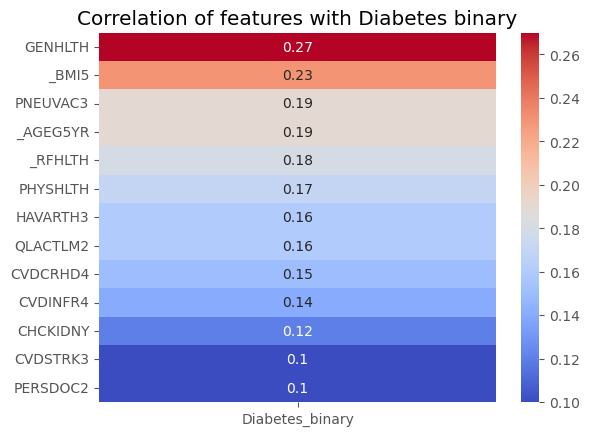

In [45]:
sns.heatmap(corr_with_target_df,annot=True,cmap='coolwarm')
plt.title("Correlation of features with Diabetes binary")
#plt.savefig("../reports/bivariate/Correlationwithdiabetes.png",bbox_inches = 'tight',dpi=150)
plt.show()

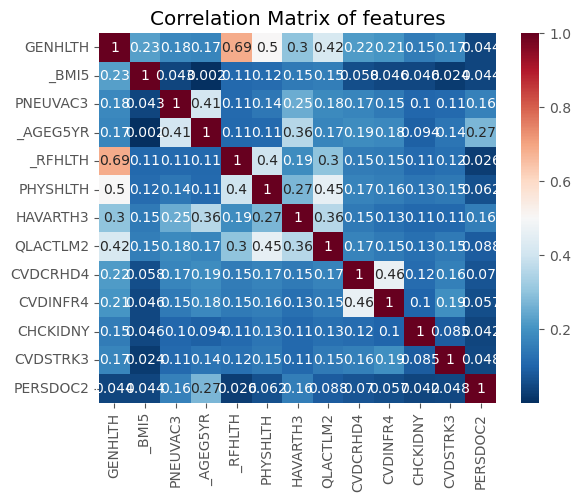

In [46]:
sns.heatmap(corr_matrix,annot=True,cmap='RdBu_r')
plt.title("Correlation Matrix of features")
#plt.savefig("../reports/bivariate/Correlationoffeatures.png",bbox_inches = 'tight',dpi=150)
plt.show()

In [47]:
df.to_csv("../data/processed/cleaned_data.csv", index=False)

## Day 5 — Binary Column Encoding, Data Cleaning & Correlation Analysis

### 1) Binary Column Encoding
- Identified 17 binary columns following BRFSS 1/2 convention
- Categorized columns into two groups based on sentinel value percentage:
  - **Negligible (<1%):** ADDEPEV2, HLTHPLN1, QLACTLM2, CHCOCNCR, HAVARTH3, 
    MEDCOST, CHCSCNCR, CVDSTRK3, CHCKIDNY, CVDCRHD4, CVDINFR4
    → Replaced 7.0/9.0 with NaN and dropped rows
  - **Significant (>1%):** PNEUVAC3 (8.44%), HIVTST6 (3.04%), 
    DRNKANY5 (4.53%), _HCVU651 (33.79%)
    → Replaced 7.0/9.0 with NaN and imputed using mode (most_frequent)
- _HCVU651 had 33.79% sentinel values — retained as healthcare coverage 
  is clinically important and missingness likely reflects MNAR bias 
  (shame/negligence in reporting)
- PERSDOC2 was a 3-category column (1=one doctor, 2=more than one, 3=no doctor)
  → Recoded to binary: 1/2 → 1 (has doctor), 3 → 0 (no doctor)
- All binary columns recoded from BRFSS convention (1/2) to ML convention (1/0)

### 2) Remaining Null Value Treatment
- **_BMI5** (5.6% missing) → Imputed with median (preferred over mean 
  due to right-skewed distribution, skewness=1.57)
- **ALCDAY5** → 888 recoded to 0 (no drinks), 777/999 dropped as sentinels
- **INCOME2** (0.4%) and **EDUCA** (0.1%) → Rows dropped (negligible loss)
- Redundant age columns **_AGE_G** and **_AGE65YR** dropped — 
  keeping _AGEG5YR (13 age bands, highest information content)

### 3) Final Dataset Shape
- Rows: 2,120,457
- Columns: 37
- Null values: 0

### 4) Correlation Analysis — Features vs Diabetes_binary
Top correlated features with target variable:

| Feature | Correlation | Interpretation |
|---|---|---|
| GENHLTH | 0.27 | General health — strongest predictor |
| _BMI5 | 0.23 | Higher BMI strongly associated with diabetes |
| PNEUVAC3 | 0.19 | Pneumonia vaccine — older/sicker population proxy |
| _AGEG5YR | 0.19 | Older age groups show higher diabetes prevalence |
| _RFHLTH | 0.18 | Poor reported health |
| PHYSHLTH | 0.17 | More bad physical health days |
| HAVARTH3 | 0.16 | Arthritis — shared inflammation pathway |
| QLACTLM2 | 0.16 | Activity limitation due to health |

### 5) Inter-Feature Correlation (Multicollinearity Check)
- No feature pairs exceeded the 0.7 multicollinearity threshold
- Closest pair: **_RFHLTH and GENHLTH at 0.69** — borderline, 
  will monitor during model training
- If either degrades model performance, _RFHLTH will be dropped 
  as GENHLTH has higher correlation with target

### 6) Key Limitations Noted
- **Reverse causality** — GENHLTH may be low because of diabetes, 
  not a cause of it
- **MNAR bias** — _HCVU651 missingness is not random, 
  likely systematic underreporting
- **Survey data** — correlations cannot imply causation

### 7) Saved Outputs
- Cleaned dataset: `data/processed/cleaned_data.csv`
- Correlation with target heatmap: `reports/bivariate/Correlationwithdiabetes.png`
- Inter-feature correlation matrix: `reports/bivariate/Correlationoffeatures.png`

### 8) PNEUVAC3 — Reverse Causality Warning
PNEUVAC3 shows 0.19 correlation with Diabetes_binary but this is 
likely a consequence proxy — diabetic patients are prescribed pneumonia 
vaccines because of their condition. For a real-world risk prediction 
tool targeting undiagnosed individuals, this feature may introduce 
misleading signals and will be reviewed before final model training.